In [280]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [281]:
df = pd.read_csv("/Users/brookeholland/PROJECTS/supply_chain_product_ops_project/data/supply_chain_data.csv")
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [282]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [283]:
df.groupby("Supplier name")[["Manufacturing costs", "Shipping costs", "Production volumes"]].mean().sort_index()

,Manufacturing costs,Shipping costs,Production volumes
Supplier name,,,
Supplier 1,45.254027,5.512302,501.666667
Supplier 2,41.622514,5.739178,641.136364
Supplier 3,43.634121,4.788771,533.133333
Supplier 4,62.709727,5.759573,653.111111
Supplier 5,44.768243,5.789832,521.166667


In [284]:
order = ["Carrier A", "Carrier B", "Carrier C"]

df["Shipping carriers"] = pd.Categorical(df["Shipping carriers"], categories=order, ordered=True)

df.groupby("Shipping carriers")["Shipping times"].mean().sort_index()

/var/folders/82/498kf3dn6ksfkb_lrgfp34c80000gn/T/ipykernel_12350/936389341.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Shipping carriers")["Shipping times"].mean().sort_index()


Shipping carriers
Carrier A    6.142857
Carrier B    5.302326
Carrier C    6.034483
Name: Shipping times, dtype: float64

In [285]:
df.groupby("Product type")[["Number of products sold", "Revenue generated"]].sum().sort_values("Revenue generated", ascending=False)

,Number of products sold,Revenue generated
Product type,,
skincare,20731,241628.162133
haircare,13611,174455.390605
cosmetics,11757,161521.265999


In [286]:
plt.rcParams.update({
    "figure.figsize": (8,5),
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

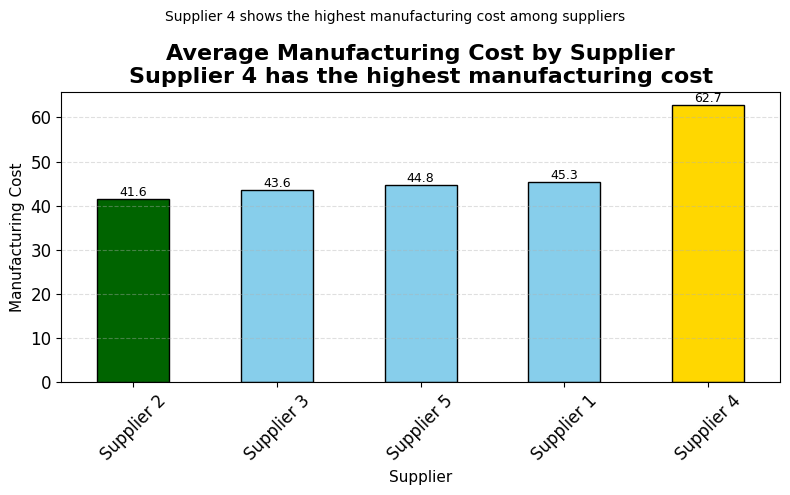

Text(0.5, 0.98, 'Supplier 4 shows the highest manufacturing cost among suppliers')

<Figure size 800x500 with 0 Axes>

In [287]:
plt.suptitle(
    "Supplier 4 shows the highest manufacturing cost among suppliers",
    fontsize=10
)

supplier_df = df.groupby("Supplier name")["Manufacturing costs"].mean().sort_values()

colors = [
    "gold" if v == supplier_df.max()
    else "darkgreen" if v == supplier_df.min()
    else "skyblue"
    for v in supplier_df
]

ax = supplier_df.plot(
    kind="bar",
    edgecolor="black",
    color=colors
)

plt.title(
    "Average Manufacturing Cost by Supplier\n"
    "Supplier 4 has the highest manufacturing cost",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Supplier")
plt.ylabel("Manufacturing Cost")

plt.grid(axis='y', linestyle='--', alpha=0.4)

# value labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.suptitle(
    "Supplier 4 shows the highest manufacturing cost among suppliers",
    fontsize=10
)

/var/folders/82/498kf3dn6ksfkb_lrgfp34c80000gn/T/ipykernel_12350/589820876.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  carrier_df = df.groupby("Shipping carriers")["Shipping times"].mean().sort_values()


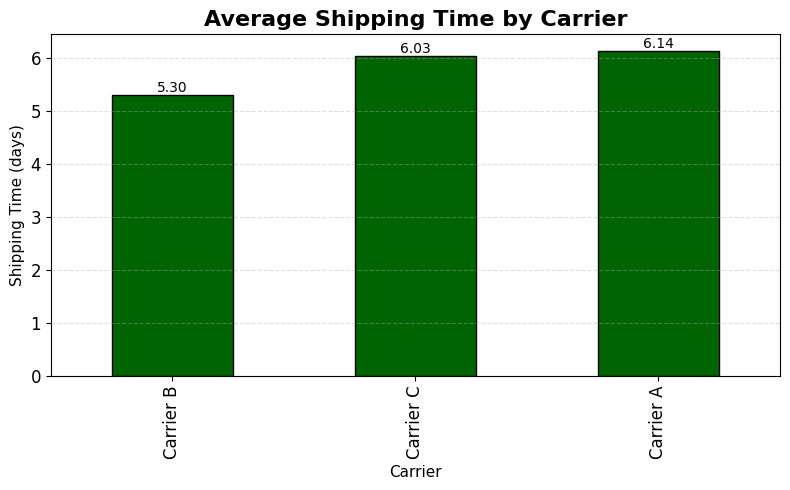

In [288]:
carrier_df = df.groupby("Shipping carriers")["Shipping times"].mean().sort_values()

ax = carrier_df.plot(kind="bar", edgecolor="black", color="darkgreen")

plt.title("Average Shipping Time by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Shipping Time (days)")

plt.grid(axis='y', linestyle='--', alpha=0.4)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

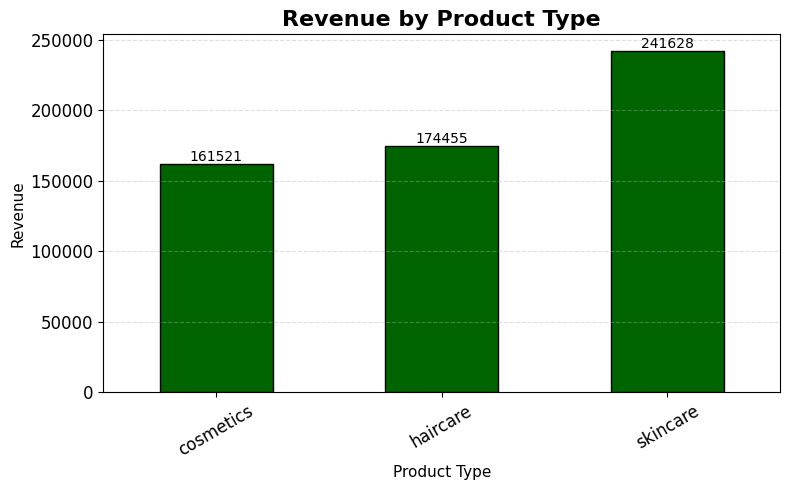

In [289]:
product_df = df.groupby("Product type")["Revenue generated"].sum().sort_values()

ax = product_df.plot(kind="bar", edgecolor="black", color="darkgreen")

plt.title("Revenue by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Revenue")

plt.grid(axis='y', linestyle='--', alpha=0.4)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/var/folders/82/498kf3dn6ksfkb_lrgfp34c80000gn/T/ipykernel_12350/934894008.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  carrier_df = df.groupby("Shipping carriers")["Shipping times"].mean().sort_values()


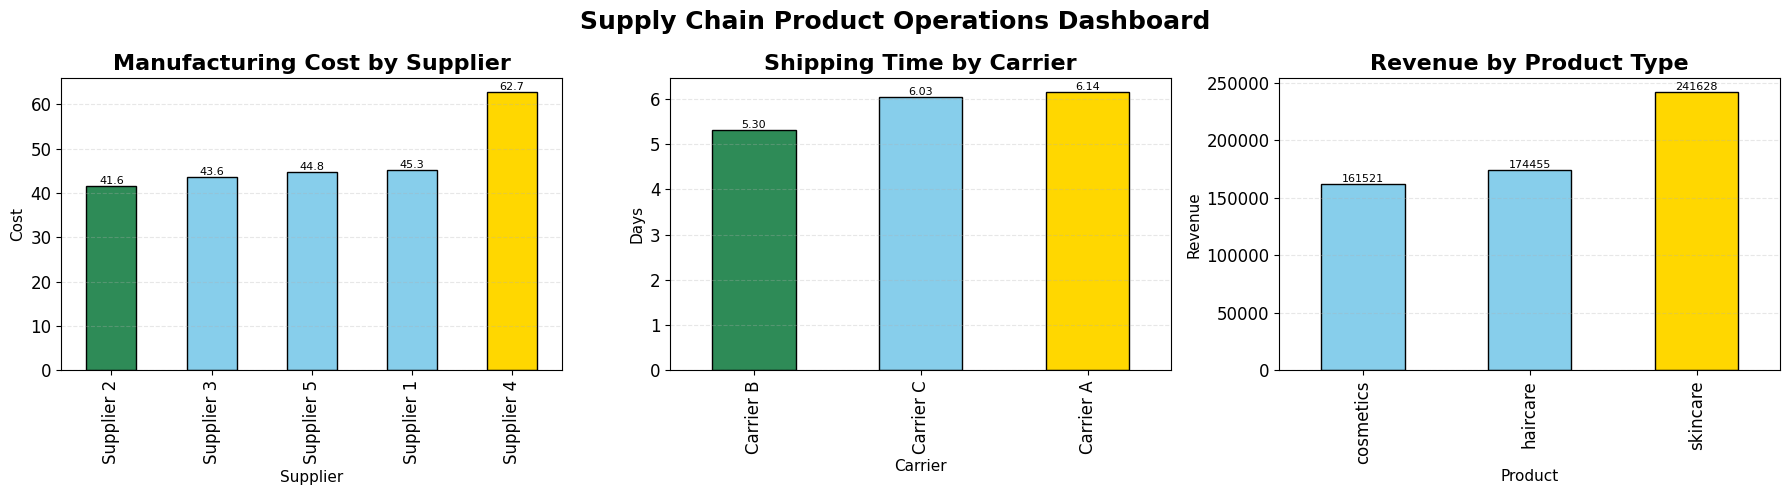

In [290]:
# --- Data Prep ---
supplier_df = df.groupby("Supplier name")["Manufacturing costs"].mean().sort_values()

carrier_df = df.groupby("Shipping carriers")["Shipping times"].mean().sort_values()

product_df = df.groupby("Product type")["Revenue generated"].sum().sort_values()


# --- Create Dashboard Layout ---
fig, axes = plt.subplots(1, 3, figsize=(18,5))

fig.suptitle(
    "Supply Chain Product Operations Dashboard",
    fontsize=18,
    fontweight="bold"
)

# =========================
# Supplier Chart
# =========================

supplier_colors = [
    "gold" if v == supplier_df.max()
    else "seagreen" if v == supplier_df.min()
    else "skyblue"
    for v in supplier_df
]

supplier_df.plot(
    kind="bar",
    ax=axes[0],
    color=supplier_colors,
    edgecolor="black"
)

axes[0].set_title("Manufacturing Cost by Supplier")
axes[0].set_xlabel("Supplier")
axes[0].set_ylabel("Cost")
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

for p in axes[0].patches:
    axes[0].annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

# =========================
# Carrier Chart
# =========================

carrier_colors = [
    "seagreen" if v == carrier_df.min()
    else "gold" if v == carrier_df.max()
    else "skyblue"
    for v in carrier_df
]

carrier_df.plot(
    kind="bar",
    ax=axes[1],
    color=carrier_colors,
    edgecolor="black"
)

axes[1].set_title("Shipping Time by Carrier")
axes[1].set_xlabel("Carrier")
axes[1].set_ylabel("Days")
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

for p in axes[1].patches:
    axes[1].annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

# =========================
# Product Revenue Chart
# =========================

product_colors = [
    "gold" if v == product_df.max()
    else "skyblue"
    for v in product_df
]

product_df.plot(
    kind="bar",
    ax=axes[2],
    color=product_colors,
    edgecolor="black"
)

axes[2].set_title("Revenue by Product Type")
axes[2].set_xlabel("Product")
axes[2].set_ylabel("Revenue")
axes[2].grid(axis='y', linestyle='--', alpha=0.3)

for p in axes[2].patches:
    axes[2].annotate(
        f'{p.get_height():.0f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

/var/folders/82/498kf3dn6ksfkb_lrgfp34c80000gn/T/ipykernel_12350/2608765918.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  carrier_df = df.groupby("Shipping carriers")["Shipping times"].mean().sort_values()


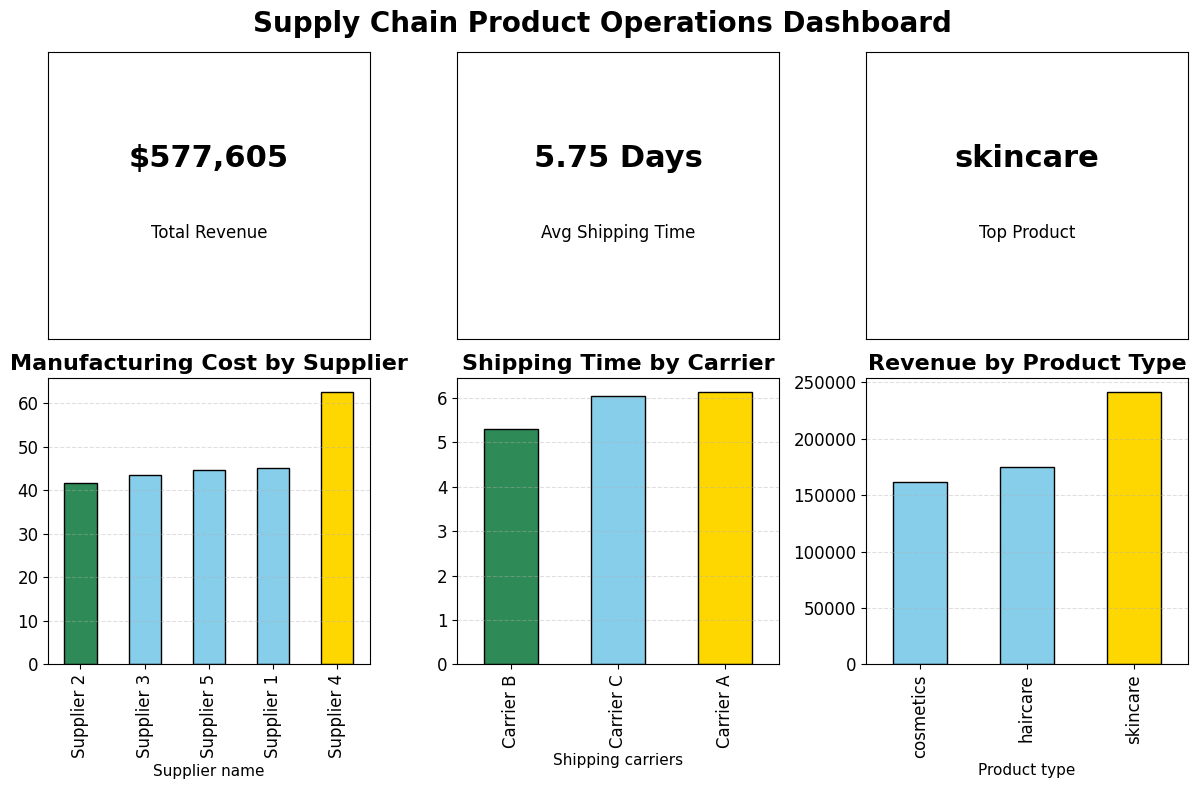

In [291]:
# =========================
# KPI Calculations
# =========================

total_revenue = df["Revenue generated"].sum()

avg_shipping = df["Shipping times"].mean()

top_product = (
    df.groupby("Product type")["Revenue generated"]
    .sum()
    .idxmax()
)

highest_supplier = (
    df.groupby("Supplier name")["Manufacturing costs"]
    .mean()
    .idxmax()
)

# =========================
# Main Dashboard Charts
# =========================

supplier_df = df.groupby("Supplier name")["Manufacturing costs"].mean().sort_values()

carrier_df = df.groupby("Shipping carriers")["Shipping times"].mean().sort_values()

product_df = df.groupby("Product type")["Revenue generated"].sum().sort_values()

# =========================
# Create Layout
# =========================

fig, axes = plt.subplots(2, 3, figsize=(12,8))

fig.suptitle(
    "Supply Chain Product Operations Dashboard",
    fontsize=20,
    fontweight="bold"
)

# =========================
# KPI CARDS (TOP ROW)
# =========================

kpis = [
    ("Total Revenue", f"${total_revenue:,.0f}"),
    ("Avg Shipping Time", f"{avg_shipping:.2f} Days"),
    ("Top Product", top_product),
]

for i, (title, value) in enumerate(kpis):
    axes[0, i].text(
        0.5, 0.6,
        value,
        fontsize=22,
        fontweight="bold",
        ha='center'
    )

    axes[0, i].text(
        0.5, 0.35,
        title,
        fontsize=12,
        ha='center'
    )

    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

    for spine in axes[0, i].spines.values():
        spine.set_visible(True)

# =========================
# Supplier Chart
# =========================

supplier_colors = [
    "gold" if v == supplier_df.max()
    else "seagreen" if v == supplier_df.min()
    else "skyblue"
    for v in supplier_df
]

supplier_df.plot(
    kind="bar",
    ax=axes[1,0],
    color=supplier_colors,
    edgecolor="black"
)

axes[1,0].set_title("Manufacturing Cost by Supplier")
axes[1,0].grid(axis='y', linestyle='--', alpha=0.4)

# =========================
# Carrier Chart
# =========================

carrier_colors = [
    "seagreen" if v == carrier_df.min()
    else "gold" if v == carrier_df.max()
    else "skyblue"
    for v in carrier_df
]

carrier_df.plot(
    kind="bar",
    ax=axes[1,1],
    color=carrier_colors,
    edgecolor="black"
)

axes[1,1].set_title("Shipping Time by Carrier")
axes[1,1].grid(axis='y', linestyle='--', alpha=0.4)

# =========================
# Product Revenue Chart
# =========================

product_colors = [
    "gold" if v == product_df.max()
    else "skyblue"
    for v in product_df
]

product_df.plot(
    kind="bar",
    ax=axes[1,2],
    color=product_colors,
    edgecolor="black"
)

axes[1,2].set_title("Revenue by Product Type")
axes[1,2].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [292]:
supplier_tableau = df.groupby("Supplier name")[[
    "Manufacturing costs",
    "Shipping costs",
    "Production volumes"
]].mean().reset_index()

carrier_tableau = df.groupby("Shipping carriers")[[
    "Shipping times"
]].mean().reset_index()

product_tableau = df.groupby("Product type")[[
    "Revenue generated",
    "Number of products sold"
]].sum().reset_index()

# Export CSVs
supplier_tableau.to_csv("../data/supplier_tableau.csv", index=False)

carrier_tableau.to_csv("../data/carrier_tableau.csv", index=False)

product_tableau.to_csv("../data/product_tableau.csv", index=False)

print("Tableau files exported successfully")

Tableau files exported successfully


/var/folders/82/498kf3dn6ksfkb_lrgfp34c80000gn/T/ipykernel_12350/3993691282.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  carrier_tableau = df.groupby("Shipping carriers")[[
